# Weather Forecast Project

#### Data Gathering

#### Uncomment the four cells below if want to fetch the data, otherwise, the complete data has already been provided in the data folder, and the cells below can be run seamlessly after installing the data files in the same directory as this notebook.

In [39]:
'''

import openmeteo_requests

import pandas as pd
import requests_cache
from retry_requests import retry

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = 3600)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://historical-forecast-api.open-meteo.com/v1/forecast"
params = {
	"latitude": 26.1844,
	"longitude": 91.7458,
	"start_date": "2025-01-01",
	"end_date": "2025-12-31",
	"hourly": ["wind_direction_10m", "wind_speed_10m"],
	"timezone": "GMT",
}
responses = openmeteo.weather_api(url, params = params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone: {response.Timezone()}{response.TimezoneAbbreviation()}")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

# Process hourly data. The order of variables needs to be the same as requested.
hourly = response.Hourly()
hourly_wind_direction_10m = hourly.Variables(0).ValuesAsNumpy()
hourly_wind_speed_10m = hourly.Variables(1).ValuesAsNumpy()

hourly_data = {
	"date": pd.date_range(
		start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
		end =  pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
		freq = pd.Timedelta(seconds = hourly.Interval()),
		inclusive = "left"
	)
}

hourly_data["wind_direction_10m"] = hourly_wind_direction_10m
hourly_data["wind_speed_10m"] = hourly_wind_speed_10m

hourly_dataframe = pd.DataFrame(data = hourly_data)
print("\nHourly data\n", hourly_dataframe)


'''

Coordinates: 26.186290740966797°N 91.77632141113281°E
Elevation: 60.0 m asl
Timezone: NoneNone
Timezone difference to GMT+0: 0s

Hourly data
                           date  wind_direction_10m  wind_speed_10m
0    2025-01-01 00:00:00+00:00          168.111359        3.494968
1    2025-01-01 01:00:00+00:00          155.095261        5.556726
2    2025-01-01 02:00:00+00:00          117.758453        3.864763
3    2025-01-01 03:00:00+00:00           33.690102        1.297998
4    2025-01-01 04:00:00+00:00            4.398633        2.346913
...                        ...                 ...             ...
8755 2025-12-31 19:00:00+00:00          135.000107        3.818376
8756 2025-12-31 20:00:00+00:00          136.548111        4.711051
8757 2025-12-31 21:00:00+00:00          143.615555        4.248152
8758 2025-12-31 22:00:00+00:00          161.564957        4.553679
8759 2025-12-31 23:00:00+00:00          157.380096        4.680000

[8760 rows x 3 columns]


In [40]:
'''
filename = "Guwahati_forecast_2025.csv"
hourly_dataframe.to_csv(filename, index=False)
print(f"Data saved to {filename}")

'''

Data saved to Guwahati_forecast_2025.csv


In [78]:
'''
import openmeteo_requests

import pandas as pd
import requests_cache
from retry_requests import retry

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = -1)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
	"latitude": 19.0728,
	"longitude": 72.8826,
	"start_date": "2025-01-01",
	"end_date": "2025-12-31",
	"hourly": ["wind_speed_10m", "wind_direction_10m"],
	"models": "era5",
	"timezone": "GMT",
}
responses = openmeteo.weather_api(url, params = params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone: {response.Timezone()}{response.TimezoneAbbreviation()}")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

# Process hourly data. The order of variables needs to be the same as requested.
hourly = response.Hourly()
hourly_wind_speed_10m = hourly.Variables(0).ValuesAsNumpy()
hourly_wind_direction_10m = hourly.Variables(1).ValuesAsNumpy()

hourly_data = {
	"date": pd.date_range(
		start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
		end =  pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
		freq = pd.Timedelta(seconds = hourly.Interval()),
		inclusive = "left"
	)
}

hourly_data["wind_speed_10m"] = hourly_wind_speed_10m
hourly_data["wind_direction_10m"] = hourly_wind_direction_10m

hourly_dataframe = pd.DataFrame(data = hourly_data)
print("\nHourly data\n", hourly_dataframe)
'''

Coordinates: 19.0°N 73.0°E
Elevation: 8.0 m asl
Timezone: NoneNone
Timezone difference to GMT+0: 0s

Hourly data
                           date  wind_speed_10m  wind_direction_10m
0    2025-01-01 00:00:00+00:00        9.021574           28.610369
1    2025-01-01 01:00:00+00:00        8.536252           42.436188
2    2025-01-01 02:00:00+00:00        7.638875           55.560955
3    2025-01-01 03:00:00+00:00        7.748368           59.264584
4    2025-01-01 04:00:00+00:00        7.093462           54.293217
...                        ...             ...                 ...
8755 2025-12-31 19:00:00+00:00        2.675892          109.653915
8756 2025-12-31 20:00:00+00:00        4.724786          107.744766
8757 2025-12-31 21:00:00+00:00        5.692100          108.435043
8758 2025-12-31 22:00:00+00:00        6.379216          106.389618
8759 2025-12-31 23:00:00+00:00        4.589118           78.690102

[8760 rows x 3 columns]


In [79]:
'''
filename = "Mumbai_historical_2025.csv"
hourly_dataframe.to_csv(filename, index=False)
print(f"Data saved to {filename}")
'''

Data saved to Mumbai_historical_2025.csv


#### Data Collation

In [48]:
import pandas as pd
import glob

# all forecast csv files
forecast_files = glob.glob("*_forecast_2025.csv")

all_dfs = []

for forecast_file in forecast_files:

    # get city name
    city = forecast_file.replace("_forecast_2025.csv", "")

    # matching historical file
    historical_file = city + "_historical_2025.csv"

    print("Processing:", city)

    # read csv files
    forecast_df = pd.read_csv(forecast_file)
    historical_df = pd.read_csv(historical_file)

    # rename columns
    forecast_df.columns = [
        "date",
        "forecast_wind_direction",
        "forecast_wind_speed"
    ]

    historical_df.columns = [
        "date",
        "actual_wind_speed",
        "actual_wind_direction"
    ]

    # merge on date
    merged_df = pd.merge(forecast_df, historical_df, on="date")

    # add location column
    merged_df["location"] = city

    # calculate bias
    merged_df["delta"] = (
        merged_df["actual_wind_speed"]
        - merged_df["forecast_wind_speed"]
    )

    # save merged city file
    merged_df.to_csv(city + "_merged.csv", index=False)

    all_dfs.append(merged_df)

    print(city, "done")

# combine all cities
master_df = pd.concat(all_dfs, ignore_index=True)

# save final dataset
master_df.to_csv("master_dataset.csv", index=False)

print("\nMaster dataset created")
print(master_df.head())

Processing: Bikaner
Bikaner done
Processing: Chennai
Chennai done
Processing: Delhi
Delhi done
Processing: Guwahati
Guwahati done
Processing: Jaisalmer
Jaisalmer done
Processing: Kochi
Kochi done
Processing: Leh
Leh done
Processing: Lucknow
Lucknow done
Processing: Mumbai
Mumbai done
Processing: Shimla
Shimla done

Master dataset created
                        date  forecast_wind_direction  forecast_wind_speed  \
0  2025-01-01 00:00:00+00:00                55.784250             5.441838   
1  2025-01-01 01:00:00+00:00                78.111370             6.989935   
2  2025-01-01 02:00:00+00:00                97.305670             7.077457   
3  2025-01-01 03:00:00+00:00               110.376520             6.720535   
4  2025-01-01 04:00:00+00:00               113.962494             3.545589   

   actual_wind_speed  actual_wind_direction location     delta  
0           8.311245               72.34979  Bikaner  2.869407  
1           8.436990               78.92985  Bikaner  1.44705

## Data Preparation

#### Adding terrain labels

In [49]:
terrain_map = {
    "Delhi": "plains",
    "Lucknow": "plains",
    "Mumbai": "coastal",
    "Chennai": "coastal",
    "Leh": "mountain",
    "Shimla": "mountain",
    "Jaisalmer": "desert",
    "Bikaner": "desert",
    "Kochi": "tropical",
    "Guwahati": "tropical"
}

master_df["terrain"] = master_df["location"].map(terrain_map)



In [50]:
# Encode terrains: One hot encoding

master_df = pd.get_dummies(master_df, columns=["terrain"])

master_df.head()

,date,forecast_wind_direction,forecast_wind_speed,actual_wind_speed,actual_wind_direction,location,delta,terrain_coastal,terrain_desert,terrain_mountain,terrain_plains,terrain_tropical
0,2025-01-01 00:00:00+00:00,55.784250,5.441838,8.311245,72.34979,Bikaner,2.869407,False,True,False,False,False
1,2025-01-01 01:00:00+00:00,78.111370,6.989935,8.436990,78.92985,Bikaner,1.447055,False,True,False,False,False
2,2025-01-01 02:00:00+00:00,97.305670,7.077457,7.922045,88.69808,Bikaner,0.844588,False,True,False,False,False
3,2025-01-01 03:00:00+00:00,110.376520,6.720535,8.297589,102.52880,Bikaner,1.577054,False,True,False,False,False
4,2025-01-01 04:00:00+00:00,113.962494,3.545589,8.431228,106.11349,Bikaner,4.885639,False,True,False,False,False


#### Adding time features

In [51]:

master_df["date"] = pd.to_datetime(master_df["date"])

master_df["hour"] = master_df["date"].dt.hour
master_df["month"] = master_df["date"].dt.month

#### Adding hour cyclic encoding and month cyclic encoding 

In [52]:
import numpy as np

master_df["hour_sin"] = np.sin(2 * np.pi * master_df["hour"] / 24)
master_df["hour_cos"] = np.cos(2 * np.pi * master_df["hour"] / 24)

master_df["month_sin"] = np.sin(2 * np.pi * master_df["month"] / 12)
master_df["month_cos"] = np.cos(2 * np.pi * master_df["month"] / 12)

#### Converting wind direction into sin/cos

In [53]:
# convert degrees to radians
forecast_rad = np.deg2rad(master_df["forecast_wind_direction"])

# direction features
master_df["dir_sin"] = np.sin(forecast_rad)
master_df["dir_cos"] = np.cos(forecast_rad)

#### Train/Test split

In [54]:
train_df = master_df[master_df["date"] < "2025-11-01"]
test_df = master_df[master_df["date"] >= "2025-11-01"]

#### Selecting the features

In [55]:
features = [
    "forecast_wind_speed",
    "dir_sin",
    "dir_cos",
    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos"
]

terrain_cols = [c for c in master_df.columns if "terrain_" in c]

features.extend(terrain_cols)

#### Defining X and y (for test and train)

In [56]:
X_train = train_df[features]
y_train = train_df["delta"]

X_test = test_df[features]
y_test = test_df["delta"]

## Model Training 

In [57]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

## Predictions

In [58]:
# Prediction of the bias
predicted_delta = model.predict(X_test)

# Correct forecast
corrected_forecast = (
    test_df["forecast_wind_speed"]
    + predicted_delta
)

## Evaluate

#### Now I test raw forecast against corrected forecast, against the actual wind speed. This is how success looks like: we want corrected RMSE < Raw RMSE.

In [59]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

# raw forecast error
raw_rmse = np.sqrt(
    mean_squared_error(
        test_df["actual_wind_speed"],
        test_df["forecast_wind_speed"]
    )
)

# corrected forecast error
corrected_rmse = np.sqrt(
    mean_squared_error(
        test_df["actual_wind_speed"],
        corrected_forecast
    )
)

print("Raw Forecast RMSE:", raw_rmse)
print("Corrected Forecast RMSE:", corrected_rmse)

Raw Forecast RMSE: 3.267833392258648
Corrected Forecast RMSE: 2.3263600121364707


There is a reduction of approximately:

$$\frac{3.2678 - 2.3264}{3.2678} \times 100 \approx 28.8\%$$

So, ~29% RMSE improvement. It is a strong result.

#### Computing more metrics

In [60]:
#### Mean absolute error


raw_mae = mean_absolute_error(
    test_df["actual_wind_speed"],
    test_df["forecast_wind_speed"]
)

corrected_mae = mean_absolute_error(
    test_df["actual_wind_speed"],
    corrected_forecast
)

print("Raw MAE:", raw_mae)
print("Corrected MAE:", corrected_mae)

#### Mean Error

raw_bias = (
    test_df["forecast_wind_speed"]
    - test_df["actual_wind_speed"]
).mean()

corrected_bias = (
    corrected_forecast
    - test_df["actual_wind_speed"]
).mean()

print("Raw Bias:", raw_bias)
print("Corrected Bias:", corrected_bias)

Raw MAE: 2.582022912894126
Corrected MAE: 1.7667022743663126
Raw Bias: -1.1644563291304646
Corrected Bias: 0.1471766276824397


These are good results.

### 1. MAE Improvement

Raw MAE: 2.582  
Corrected MAE: 1.767

Improvement:

$$
\frac{2.582 - 1.767}{2.582} \times 100 \approx 31.6\%
$$

So, ~32% reduction in MAE. MAE tells average absolute wind-speed error so after correction my forecast became substantially closer to reality on average.

### 2. Bias Improvement

Raw Bias: −1.164
After Correction: 0.147

This means the original forecast systematically under predicted wind speed, because forecast − actual < 0. Now the systematic bias is almost eliminated. My ML model has successfully learned systematic underprediction structure and corrected it. My corrected forecast is now much less biased, substantially more accurate, lower RMSE, lower MAE.


### My Final Results So Far

| Metric | Raw Forecast | Corrected Forecast |
|--------|--------------|-------------------|
| RMSE   | 3.27         | 2.33              |
| MAE    | 2.58         | 1.77              |
| Bias   | -1.16        | 0.15              |



The bias moving from −1.16 to 0.15 is very significant because raw forecast consistently underestimated winds and corrected model removed systematic offset. This is often operationally more important than RMSE alone. 

The conclusion is that, the ML-based residual correction substantially improved forecast skill across all major evaluation metrics. RMSE decreased by ~29%, MAE decreased by ~32%, and systematic forecast bias was nearly eliminated.

#### Feature importance: which features matter the most

In [61]:
importance_df = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print(importance_df)

                feature  importance
0   forecast_wind_speed    0.290430
8        terrain_desert    0.186475
2               dir_cos    0.114727
1               dir_sin    0.107176
11     terrain_tropical    0.061644
3              hour_sin    0.052710
4              hour_cos    0.048782
5             month_sin    0.042106
9      terrain_mountain    0.037214
6             month_cos    0.036466
7       terrain_coastal    0.013152
10       terrain_plains    0.009119


### Important Features 

Most Important Feature is forecast_wind_speed with importance ≈ 0.290. This means that forecast magnitude strongly influences correction size. Desert Terrain is the next important feature with importance ≈ 0.186. My model discovered that desert regions have distinct forecast bias behavior. Likely reasons could be that intense daytime heating causes convective turbulence which makes wind prediction harder. This is why terrain diversity was important. I also wind that wind direction matters strongly with importnce ≈ 0.22 for sin and cos combined. This makes physical sense because terrain interaction depends on direction, for example, mountain blocking depends on direction, coastal sea breeze depends on direction. Tropical Terrain also matters with importance ≈ 0.62. This likely reflects monsoon effects and instability in the tropical environments. Time of day effects matter with combined importance of hour_sin and hour_cos ≈ 0.10, may be due to turbulence due to heat and sun in the afternoon and stability during the night. Seasonal effects matter somewhat with importance ≈ 0.078 ( month_sin and month_cos) combined. Monsoon/winter/summer patterns influence forecast bias. Mountain terrain importance is surprisingly lower ≈ 0.037. May be because there are only two mountain locations, insufficient extreme events, or ECMWF already handles mountains relatively well there.

We have a very important scientific insight from our discussion that the feature importance ranking is meteorologically interpretable, and my model is not behaving randomly. There is another key finding that terrain categories are not all equally important.

#### Here I present now the terrain wise calculation of the computation metrics

In [62]:
terrain_results = []

terrain_columns = [
    "terrain_coastal",
    "terrain_desert",
    "terrain_mountain",
    "terrain_plains",
    "terrain_tropical"
]

for terrain_col in terrain_columns:

    terrain_df = test_df[test_df[terrain_col] == True]

    raw_rmse = np.sqrt(
        mean_squared_error(
            terrain_df["actual_wind_speed"],
            terrain_df["forecast_wind_speed"]
        )
    )

    corrected_rmse = np.sqrt(
        mean_squared_error(
            terrain_df["actual_wind_speed"],
            terrain_df["forecast_wind_speed"]
            + model.predict(terrain_df[features])
        )
    )

    terrain_results.append({
        "terrain": terrain_col.replace("terrain_", ""),
        "raw_rmse": raw_rmse,
        "corrected_rmse": corrected_rmse
    })

terrain_results_df = pd.DataFrame(terrain_results)

print(terrain_results_df)

    terrain  raw_rmse  corrected_rmse
0   coastal  3.235230        2.525954
1    desert  4.115393        3.050073
2  mountain  2.911297        1.618701
3    plains  3.039613        2.048867
4  tropical  2.876735        2.135021


### Interpretation

Desert Had Largest Raw Error with Raw RMSE ≈ 4.12, which is the largest among all terrains. This could be due to strong daytime heating and thermal turbulence which could cause rapidly changing winds. This causes the numerical weather model to struggle there. This aligns aligns perfectly with my feature importance result. We also observe that mountain terrain improved most, with RMSE moving from 2.91 to 1.62. This is a huge improvement. This is interesting because mountain winds are strongly influenced by valleys, slopes, terrain blocking and local directional effects. My ML model likely learned terrain dependent directional residual structure. The raw forecast was already decent in mountains, but the ML correction learned systematic residual patterns extremely effectively. Plains improved strongly with RMSE moving from 3.04 to 2.05, which reflects easier learnable residual structure at the plains. Coastal and tropical improvements were moderate likely because coastal winds involve sea-breeze transitions, moist convection and monsoon variability.

#### RMSE comparison plot

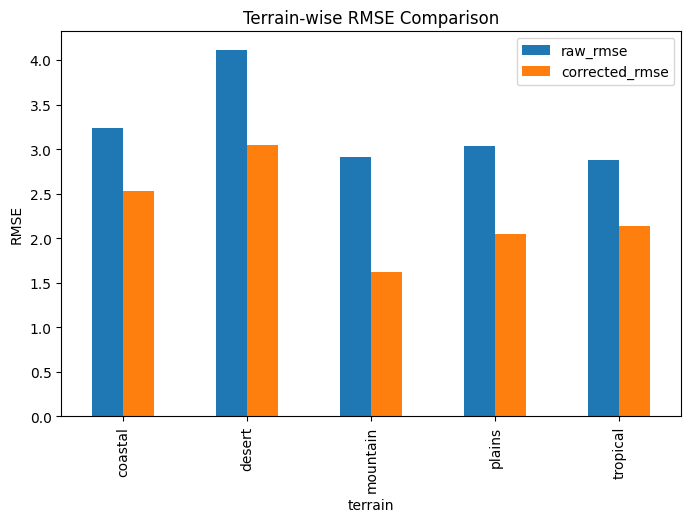

In [63]:
terrain_results_df.plot(
    x="terrain",
    y=["raw_rmse", "corrected_rmse"],
    kind="bar",
    figsize=(8,5)
)

plt.ylabel("RMSE")
plt.title("Terrain-wise RMSE Comparison")

plt.savefig("rmse_comparison.png")
plt.show()



#### Feature importance plot

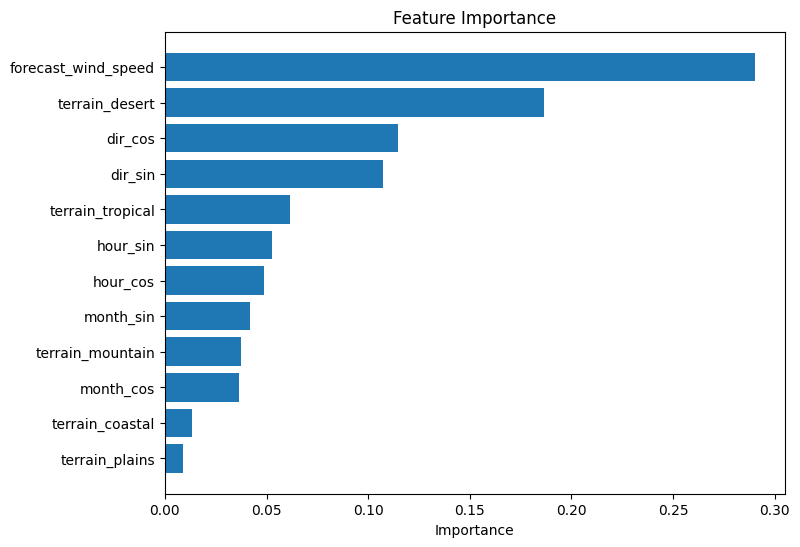

In [64]:
importance_df = importance_df.sort_values(
    by="importance",
    ascending=True
)

plt.figure(figsize=(8,6))

plt.barh(
    importance_df["feature"],
    importance_df["importance"]
)

plt.xlabel("Importance")
plt.title("Feature Importance")

plt.savefig("feature_importance.png")
plt.show()



#### Actual vs Corrected Forecast plot

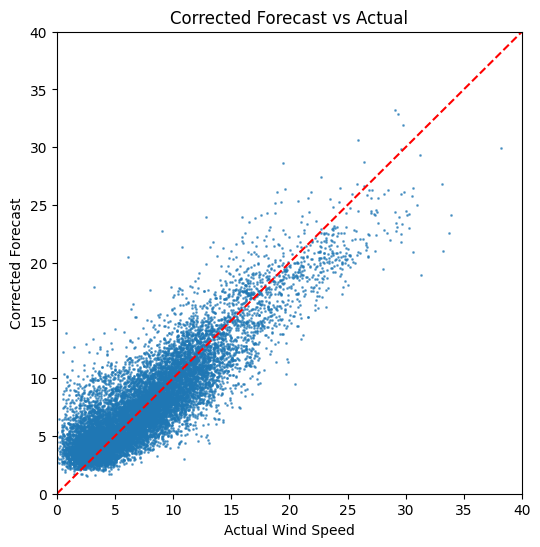

In [65]:
plt.figure(figsize=(6,6))

plt.scatter(
    test_df["actual_wind_speed"],
    corrected_forecast,
    alpha=0.6, s=1
)

# perfect prediction line
plt.plot(
    [0, 40],
    [0, 40],
    linestyle="--", color= "red"
)

plt.xlabel("Actual Wind Speed")
plt.ylabel("Corrected Forecast")

plt.title("Corrected Forecast vs Actual")
plt.xlim([0,40])
plt.ylim([0,40])
plt.savefig("CorrectedvsActual.png")
plt.show()



#### INTERPRETATION

Points on the line perfect predictions. Points below the line mean corrected forecast < actual wind speed, so the model underestimated wind speed. Points above the line mean corrected forecast > actual wind speed, so the model overestimated wind speed.

In my results we find strong Diagonal Alignment. This is good. Most points roughly follow the diagonal trend, meaning the model learned actual atmospheric structure and the corrected forecasts correlate well with reality. This result supports my RMSE improvement and my MAE improvement. We observe dense cluster at low-to-mid Wind Speeds. Most points are concentrated around 0−15 m/s. This is expected because moderate winds occur much more frequently in nature. The model performs reasonably well there. We observe an increasing spread at higher wind speeds. As actual wind increases the cloud widens this means uncertainty/error increases for strong winds. This is very physically realistic because strong winds often involve storms, turbulence and rapidly evolving atmospheric states. These are inherently harder to predict. There is another very important observation which is systematic underprediction at High Winds. We notice something very important: for x > 25 many points lie below the diagonal line. This means that corrected forecasts still underestimate strong winds. This possibly happens because the model saw fewer examples of 30–40 m/s winds. This could also be because Random Forest fails at extreme values. Extreme winds are harder for simple tabular ML to capture.

So, a limitation of the model is poor prediction at extreme values due to sparse data, and failing of a simple ML model. Otherwise the model is excellent at correcting normal operational winds. 

Another interesting observation is 0−10 m/s Points slightly above line, that is, a slight overprediction of weak winds, and 25−40 m/s points fall below the line, that is, an underprediction of strong winds.

#### Saving the Final Corrected Dataset

In [66]:
test_df["predicted_delta"] = predicted_delta

test_df["corrected_forecast"] = corrected_forecast

test_df.to_csv("corrected_forecast_results.csv", index=False)

## Seasonal analysis Plot

In [69]:
#### First creating predictions for all data:

all_predicted_delta = model.predict(master_df[features])

all_corrected_forecast = (
    master_df["forecast_wind_speed"]
    + all_predicted_delta
)




monthly_results = []

for month in range(1, 13):

    month_df = master_df[master_df["month"] == month]

    raw_rmse_month = np.sqrt(
        mean_squared_error(
            month_df["actual_wind_speed"],
            month_df["forecast_wind_speed"]
        )
    )

    corrected_rmse_month = np.sqrt(
        mean_squared_error(
            month_df["actual_wind_speed"],
            all_corrected_forecast[month_df.index]
        )
    )

    monthly_results.append({
        "month": month,
        "raw_rmse": raw_rmse_month,
        "corrected_rmse": corrected_rmse_month
    })

monthly_results_df = pd.DataFrame(monthly_results)

print(monthly_results_df)



    month  raw_rmse  corrected_rmse
0       1  3.915267        0.746578
1       2  3.863761        0.805024
2       3  4.190117        0.985655
3       4  4.255206        1.075511
4       5  4.979134        1.237595
5       6  5.257034        1.136397
6       7  5.435489        1.148115
7       8  4.991591        1.061220
8       9  4.267520        0.952281
9      10  3.739206        0.925190
10     11  3.495630        2.408801
11     12  3.031128        2.243696


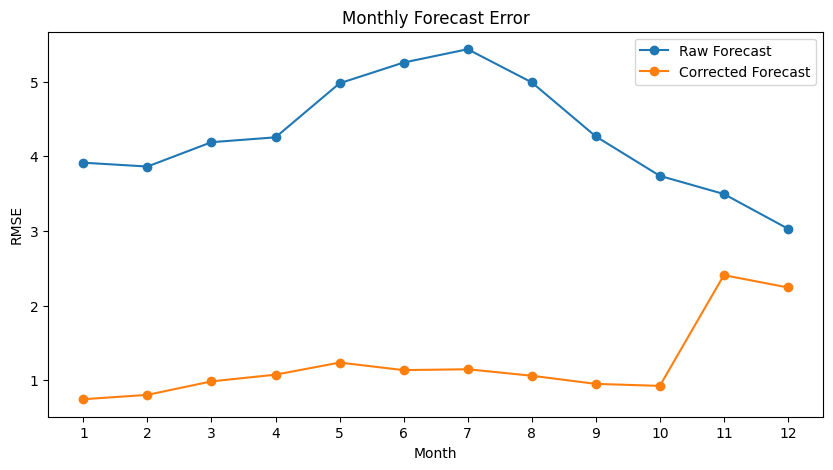

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    monthly_results_df["month"],
    monthly_results_df["raw_rmse"],
    marker="o",
    label="Raw Forecast"
)

plt.plot(
    monthly_results_df["month"],
    monthly_results_df["corrected_rmse"],
    marker="o",
    label="Corrected Forecast"
)

plt.xlabel("Month")

plt.ylabel("RMSE")

plt.title("Monthly Forecast Error")

plt.xticks(range(1,13))

plt.legend()

plt.savefig("Monthly forecast error.png")
plt.show()

#### Interpretation:

My ML correction is consistently helping across all seasons. That is the key conclusion. The orange curve stays below the blue curve everywhere, which implies, the corrected forecast is always better. My ML correction improved forecast in winter, summer, during monsoon transition periods and across the entire year. Another important observation is the raw forecast errors peak mid-year, which is implied by blue curve rising strongly around May to August with maximum around June/July. This is very physically reasonable, because these months correspond approximately to Indian summer + monsoon onset period. These are dynamically active atmospheric periods, and so forecast difficulty naturally increases. Another observation is that ML Correction Helps most during difficult months. When raw RMSE becomes very high corrected RMSE remains relatively stable. Especially around May−August the correction system suppresses error dramatically. orange curve increases in Nov−Dec. The model never trained on them directly so generalization becomes harder but also seasonal shift occurs.

## Limitations of our analysis are:

1. Only one year used
2. Sparse data at high winds, hence poor predictability
3. Random Forest struggles on extremes.